# Notebook 06 — Test the Ternary KD+QAT Student on Unseen Images

Loads the trained ternary ResNet18 student (KD+QAT checkpoint) and runs inference on a local folder of 200 images, producing report-ready plots: prediction distribution, confidence histogram, a sample prediction grid, and (if the images are labeled) an accuracy score + confusion matrix.

**Before running:** set `image_dir` in Step 2 to your actual local path.

## Step 1 — Load the trained student
Adjust the architecture-building call and checkpoint path to match what you used in Notebook 05 if they differ from the defaults below.

In [4]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
from src.resnet_cifar import resnet18_cifar
from src.ternary import TernaryConv2d, TernaryLinear

D = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', D)

# Exact construction call used in Notebook 05, cell 3.
student = resnet18_cifar(
    num_classes=10,
    conv_layer=TernaryConv2d,
    linear_layer=TernaryLinear,
    first_last_fp32=True,
).to(D)

checkpoint_path = './checkpoints/student_ternary_resnet18_best.pth'
checkpoint = torch.load(checkpoint_path, map_location=D)
student.load_state_dict(checkpoint["model_state_dict"])   
student.eval()
print(f'Ternary KD+QAT student loaded from {checkpoint_path} and set to eval mode.')

Using device: cuda
Ternary KD+QAT student loaded from ./checkpoints/student_ternary_resnet18_best.pth and set to eval mode.


## Step 2 — Point to your 200-image folder and set up preprocessing
CIFAR-10 normalization stats and a resize-to-32x32 transform, matching what the model was trained on.

In [8]:
import os
import glob
from PIL import Image
import torchvision.transforms as T

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

transform = T.Compose([
    T.Resize((32, 32)),
    T.ToTensor(),
    T.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

image_dir = "./Unseen Data"

image_paths = (
    glob.glob(os.path.join(image_dir, "*.jpg")) +
    glob.glob(os.path.join(image_dir, "*.jpeg")) +
    glob.glob(os.path.join(image_dir, "*.png"))
)

print(f"Found {len(image_paths)} images in '{image_dir}'")

Found 200 images in './Unseen Data'


## Step 3 — Run inference in batches

In [9]:
@torch.no_grad()
def predict_folder(model, image_paths, device, batch_size=32):
    model.eval()
    all_preds, all_conf, all_probs = [], [], []
    for i in range(0, len(image_paths), batch_size):
        batch = torch.stack([
            transform(Image.open(p).convert('RGB')) for p in image_paths[i:i + batch_size]
        ]).to(device)
        probs = torch.softmax(model(batch), dim=1)
        conf, pred = probs.max(dim=1)
        all_preds.extend(pred.cpu().tolist())
        all_conf.extend(conf.cpu().tolist())
        all_probs.append(probs.cpu())
    return all_preds, all_conf, torch.cat(all_probs, dim=0)

preds, confidences, probs = predict_folder(student, image_paths, D)
pred_labels = [CIFAR10_CLASSES[p] for p in preds]
print(f'Ran inference on {len(image_paths)} images.')


Ran inference on 200 images.


## Step 4 — Plot: prediction distribution across the 10 classes

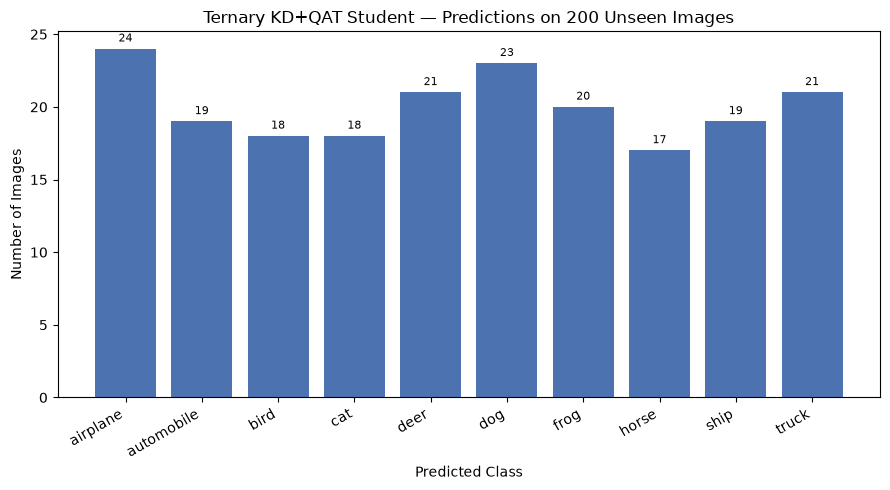

In [10]:
import matplotlib.pyplot as plt
from collections import Counter

os.makedirs('../results', exist_ok=True)

counts = Counter(pred_labels)
ordered = [counts.get(c, 0) for c in CIFAR10_CLASSES]

plt.figure(figsize=(9, 5))
bars = plt.bar(CIFAR10_CLASSES, ordered, color='#4C72B0')
plt.xlabel('Predicted Class')
plt.ylabel('Number of Images')
plt.title(f'Ternary KD+QAT Student — Predictions on {len(image_paths)} Unseen Images')
plt.xticks(rotation=30, ha='right')
for b, v in zip(bars, ordered):
    plt.text(b.get_x() + b.get_width() / 2, v + 0.5, str(v), ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('../results/student_unseen_prediction_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 5 — Plot: confidence histogram and a sample prediction grid

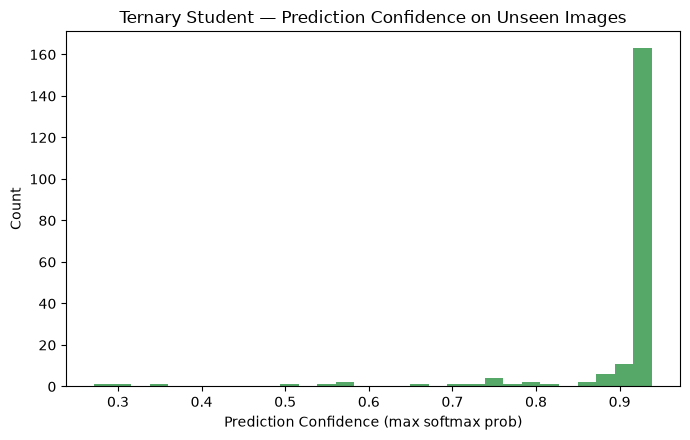

In [11]:
# Confidence histogram
plt.figure(figsize=(7, 4.5))
plt.hist(confidences, bins=30, color='#55A868')
plt.xlabel('Prediction Confidence (max softmax prob)')
plt.ylabel('Count')
plt.title('Ternary Student — Prediction Confidence on Unseen Images')
plt.tight_layout()
plt.savefig('../results/student_unseen_confidence_histogram.png', dpi=150, bbox_inches='tight')
plt.show()


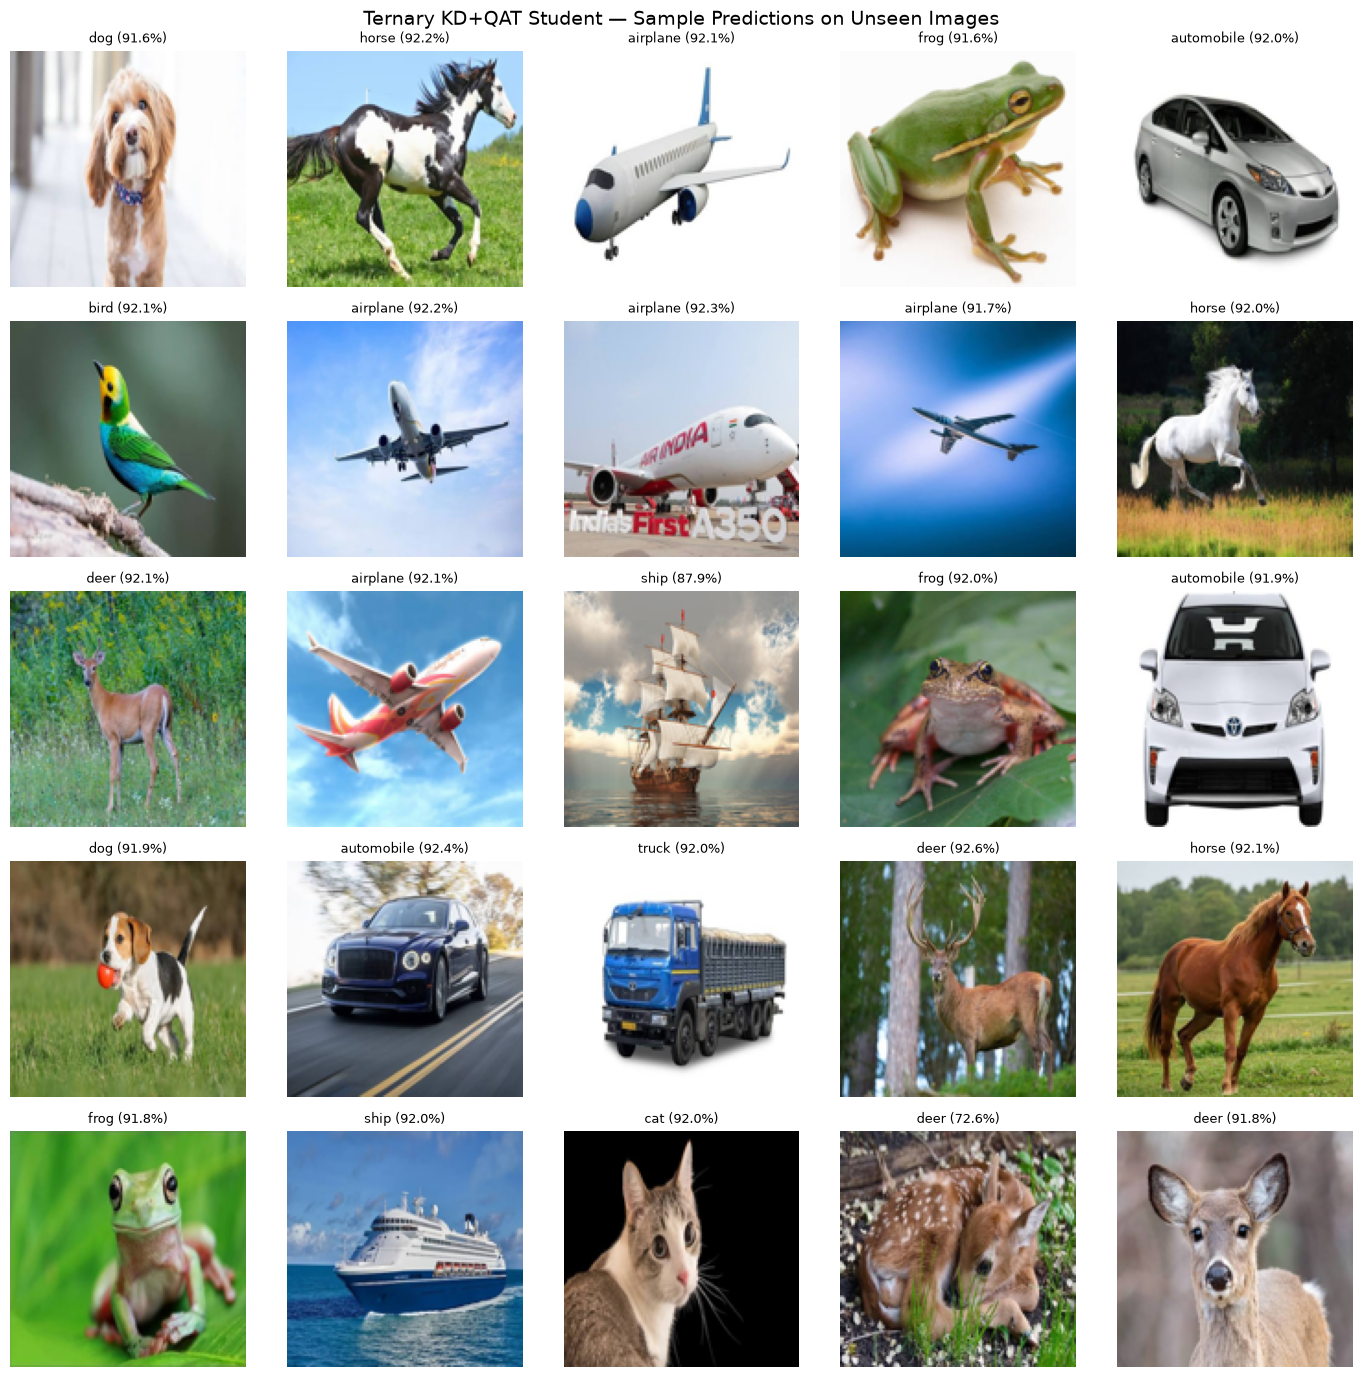

In [12]:
# Sample grid of up to 25 images with predicted label + confidence
import random

sample_idx = random.sample(range(len(image_paths)), min(25, len(image_paths)))
fig, axes = plt.subplots(5, 5, figsize=(14, 14))
for ax, idx in zip(axes.flat, sample_idx):
    img = Image.open(image_paths[idx]).convert('RGB').resize((128, 128))
    ax.imshow(img)
    ax.set_title(f'{pred_labels[idx]} ({confidences[idx]*100:.1f}%)', fontsize=9)
    ax.axis('off')
plt.suptitle('Ternary KD+QAT Student — Sample Predictions on Unseen Images', fontsize=14)
plt.tight_layout()
plt.savefig('../results/student_unseen_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
